# Questão 3 - Média Ponderada em Níveis de Cinza

Notebook para combinar duas imagens por média ponderada manual dos níveis de cinza.

Regras atendidas:
- OpenCV será usado apenas para carregar e salvar imagens.
- Conversão para cinza e combinação ponderada serão implementadas manualmente.
- Serão geradas as combinações: (0.2, 0.8), (0.5, 0.5) e (0.8, 0.2).

## 1. Configurar o ambiente no Jupyter

Esta etapa verifica versão do Python e presença das dependências necessárias para execução do processo.

## 2. Importar bibliotecas e definir parâmetros

Definimos caminhos de entrada e saída, nomes dos arquivos e pesos para reprodução do experimento.

## 3. Carregar dados/entradas do processo

As imagens serão lidas do diretório de entrada e validadas quanto a existência e dimensões compatíveis.

## 4. Implementar funções do processo

Funções reutilizáveis para: conversão manual para cinza, média ponderada manual e cálculo de métricas simples.

## 5. Executar o processo passo a passo

Processaremos cada combinação de pesos e exibiremos saídas intermediárias para inspeção.

## 6. Validar resultados com testes rápidos

Aplicaremos asserts de sanidade para confirmar formato, tipo e intervalo dos valores.

## 7. Visualizar métricas e saídas

Mostraremos as imagens geradas e estatísticas resumidas de intensidade.

## 8. Salvar resultados e artefatos

As imagens finais serão salvas no diretório de imagens e um arquivo JSON registrará timestamp e parâmetros da execução.

In [1]:
# Secao 1 - Configurar o ambiente no Jupyter
import sys

print(f"Python: {sys.version}")

Python: 3.14.3 (main, Feb 13 2026, 15:31:44) [GCC 15.2.1 20260209]


In [2]:
# Secao 2 - Importar bibliotecas e definir parametros
from pathlib import Path
from datetime import datetime
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt

PASTA_IMAGENS = Path("/home/william/Projetos/PI/imagens questao 3")
ARQ_1 = PASTA_IMAGENS / "bermuda.jpg"
ARQ_2 = PASTA_IMAGENS / "blusa.jpg"

COMBINACOES = [
    (0.2, 0.8, "resultado_0.2_0.8.png"),
    (0.5, 0.5, "resultado_0.5_0.5.png"),
    (0.8, 0.2, "resultado_0.8_0.2.png"),
]

In [3]:
# Secao 3 - Carregar dados/entradas do processo
img1 = cv2.imread(str(ARQ_1))
img2 = cv2.imread(str(ARQ_2))

if img1 is None:
    raise FileNotFoundError(f"Imagem nao encontrada ou invalida: {ARQ_1}")
if img2 is None:
    raise FileNotFoundError(f"Imagem nao encontrada ou invalida: {ARQ_2}")

if img1.shape[:2] != img2.shape[:2]:
    raise ValueError(
        f"As imagens precisam ter o mesmo tamanho. Recebido: {img1.shape[:2]} e {img2.shape[:2]}"
    )

print(f"Entrada 1: {ARQ_1.name}, shape={img1.shape}, dtype={img1.dtype}")
print(f"Entrada 2: {ARQ_2.name}, shape={img2.shape}, dtype={img2.dtype}")

Entrada 1: bermuda.jpg, shape=(400, 680, 3), dtype=uint8
Entrada 2: blusa.jpg, shape=(400, 680, 3), dtype=uint8


In [4]:
# Secao 4 - Implementar funcoes do processo

def para_cinza_manual(img: np.ndarray) -> np.ndarray:
    """Converte BGR para cinza manualmente por luminancia (0.114B + 0.587G + 0.299R)."""
    if img.ndim == 2:
        return img.astype(np.float32)

    b = img[:, :, 0].astype(np.float32)
    g = img[:, :, 1].astype(np.float32)
    r = img[:, :, 2].astype(np.float32)
    return 0.114 * b + 0.587 * g + 0.299 * r


def media_ponderada_manual(gray1: np.ndarray, gray2: np.ndarray, w1: float, w2: float) -> np.ndarray:
    """Calcula blend ponderado manualmente sem usar funcao pronta de blend."""
    combinado = (w1 * gray1) + (w2 * gray2)
    return np.clip(combinado, 0, 255).astype(np.uint8)


def resumo_metricas(img: np.ndarray) -> dict:
    """Retorna metricas basicas de intensidade para inspecao."""
    return {
        "min": int(img.min()),
        "max": int(img.max()),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
    }

In [5]:
# Secao 5 - Executar o processo passo a passo
gray1 = para_cinza_manual(img1)
gray2 = para_cinza_manual(img2)

resultados = []
metricas = {}

for w1, w2, nome_saida in COMBINACOES:
    saida = media_ponderada_manual(gray1, gray2, w1, w2)
    resultados.append((w1, w2, nome_saida, saida))
    metricas[nome_saida] = resumo_metricas(saida)
    print(f"Processado {nome_saida} com pesos ({w1}, {w2})")

print("Total de saidas processadas:", len(resultados))

Processado resultado_0.2_0.8.png com pesos (0.2, 0.8)
Processado resultado_0.5_0.5.png com pesos (0.5, 0.5)
Processado resultado_0.8_0.2.png com pesos (0.8, 0.2)
Total de saidas processadas: 3


In [6]:
# Secao 6 - Validar resultados com testes rapidos
assert gray1.shape == gray2.shape, "As imagens em cinza devem ter o mesmo shape"
assert len(resultados) == 3, "Devem existir exatamente 3 resultados"

for w1, w2, nome_saida, saida in resultados:
    assert saida.dtype == np.uint8, f"Tipo invalido em {nome_saida}: {saida.dtype}"
    assert saida.shape == gray1.shape, f"Shape invalido em {nome_saida}: {saida.shape}"
    assert int(saida.min()) >= 0 and int(saida.max()) <= 255, f"Faixa invalida em {nome_saida}"

print("Validacoes concluidas com sucesso.")

Validacoes concluidas com sucesso.


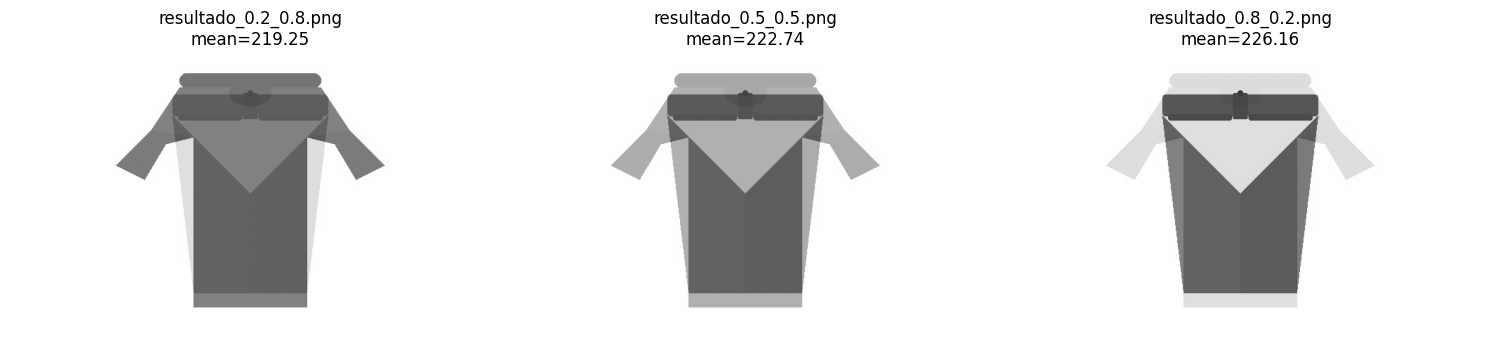

{'resultado_0.2_0.8.png': {'min': 76,
  'max': 255,
  'mean': 219.24769485294118,
  'std': 62.557639158721194},
 'resultado_0.5_0.5.png': {'min': 65,
  'max': 255,
  'mean': 222.7375992647059,
  'std': 57.92740870211917},
 'resultado_0.8_0.2.png': {'min': 55,
  'max': 255,
  'mean': 226.16017647058823,
  'std': 57.79662802573632}}

In [7]:
# Secao 7 - Visualizar metricas e saidas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (w1, w2, nome_saida, saida) in zip(axes, resultados):
    ax.imshow(saida, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{nome_saida}\nmean={metricas[nome_saida]['mean']:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

metricas

In [8]:
# Secao 8 - Salvar resultados e artefatos
for w1, w2, nome_saida, saida in resultados:
    caminho_saida = PASTA_IMAGENS / nome_saida
    ok = cv2.imwrite(str(caminho_saida), saida)
    if not ok:
        raise IOError(f"Falha ao salvar: {caminho_saida}")
    print(f"Imagem salva: {caminho_saida}")

artefato_execucao = {
    "timestamp": datetime.now().isoformat(),
    "entradas": [str(ARQ_1), str(ARQ_2)],
    "combinacoes": [{"w1": w1, "w2": w2, "arquivo": nome} for w1, w2, nome in COMBINACOES],
    "metricas": metricas,
}

arquivo_metricas = PASTA_IMAGENS / "resultado_metricas_execucao.json"
with open(arquivo_metricas, "w", encoding="utf-8") as f:
    json.dump(artefato_execucao, f, indent=2, ensure_ascii=False)

print(f"Artefato salvo: {arquivo_metricas}")

Imagem salva: /home/william/Projetos/PI/imagens questao 3/resultado_0.2_0.8.png
Imagem salva: /home/william/Projetos/PI/imagens questao 3/resultado_0.5_0.5.png
Imagem salva: /home/william/Projetos/PI/imagens questao 3/resultado_0.8_0.2.png
Artefato salvo: /home/william/Projetos/PI/imagens questao 3/resultado_metricas_execucao.json
